
# Notebook 5 — Fatigue Level & Progression Analysis

**Project:** Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning

This notebook uses the selected **MobileNetV2** model to convert four-class facial-state predictions into three fatigue levels and analyze fatigue progression.

### Four-class model outputs
- `Closed`
- `Open`
- `no_yawn`
- `yawn`

### Fatigue fusion rules
| Facial state | Fatigue level | Score |
|---|---|---:|
| Open + no_yawn | Alert | 0 |
| yawn | Mild Fatigue | 1 |
| Closed | Severe Fatigue | 2 |

### Important dataset limitation

The current dataset contains **independent images**, not timestamped video frames. Therefore, this notebook first demonstrates the fatigue-fusion logic and a **sequential sample progression analysis** using the ordered test images.

A true time-based fatigue progression curve should be generated later from continuous video/webcam frames where the frame order and timestamps represent the driver's actual sequence.


In [1]:

# Cell 1 — Imports

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
print("Notebook 5 initialized successfully.")


TensorFlow version: 2.21.0
Notebook 5 initialized successfully.


In [2]:

# Cell 2 — Configuration

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_NAMES = ["Closed", "Open", "no_yawn", "yawn"]

# Project-level paths from the notebooks folder
OUTPUTS_DIR = "../outputs"
MODELS_DIR = "../models"

TEST_CSV = os.path.join(OUTPUTS_DIR, "test_split.csv")
MODEL_PATH = os.path.join(MODELS_DIR, "mobilenetv2_final.keras")

FUSION_OUTPUT_PATH = os.path.join(
    OUTPUTS_DIR,
    "fatigue_predictions.csv"
)

PROGRESSION_OUTPUT_PATH = os.path.join(
    OUTPUTS_DIR,
    "fatigue_progression.csv"
)

# Number of predictions in one analysis window.
# This is a sample-based window, not a real minute because the dataset
# does not contain timestamped video frames.
WINDOW_SIZE = 30

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration ready.")
print("Selected model:", MODEL_PATH)
print("Window size:", WINDOW_SIZE, "samples")


Configuration ready.
Selected model: ../models\mobilenetv2_final.keras
Window size: 30 samples


In [3]:

# Cell 3 — Verify Required Files

required_files = [TEST_CSV, MODEL_PATH]

for file_path in required_files:
    status = "FOUND" if os.path.exists(file_path) else "MISSING"
    print(f"{status}: {os.path.abspath(file_path)}")


FOUND: d:\driver-drowsiness-detection\outputs\test_split.csv
FOUND: d:\driver-drowsiness-detection\models\mobilenetv2_final.keras


In [4]:

# Cell 4 — Load Test Data and MobileNetV2

test_df = pd.read_csv(TEST_CSV)
model = keras.models.load_model(MODEL_PATH)

print("Test samples:", len(test_df))
print("Model:", model.name)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


Test samples: 435
Model: MobileNetV2_Drowsiness
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 4)


In [5]:

# Cell 5 — Image Preprocessing

def load_image_for_prediction(file_path):
    image = Image.open(file_path).convert("RGB")
    image = image.resize(IMG_SIZE)
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    return image_array

print("Prediction preprocessing function created.")


Prediction preprocessing function created.


In [6]:

# Cell 6 — Generate MobileNetV2 Predictions

image_batch = np.stack(
    [load_image_for_prediction(path) for path in test_df["filepath"]]
)

probabilities = model.predict(
    image_batch,
    batch_size=BATCH_SIZE,
    verbose=1
)

predicted_indices = np.argmax(probabilities, axis=1)
predicted_classes = [
    CLASS_NAMES[index] for index in predicted_indices
]

confidence = np.max(probabilities, axis=1)

print("Predictions generated:", len(predicted_classes))
print("Prediction distribution:")
print(pd.Series(predicted_classes).value_counts())


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 557ms/step
Predictions generated: 435
Prediction distribution:
no_yawn    174
Open       110
Closed     108
yawn        43
Name: count, dtype: int64



## Fatigue Decision Fusion

The four facial-state predictions are converted into three fatigue levels using the project rules.

**Alert = 0 → Mild Fatigue = 1 → Severe Fatigue = 2**

Note that the raw MobileNetV2 class indices are not themselves fatigue scores. The fatigue score is assigned only after applying the rule-based mapping.


In [7]:

# Cell 7 — Apply Fatigue Fusion Rules

def map_fatigue_level(predicted_class):
    if predicted_class == "Closed":
        return "Severe Fatigue", 2
    elif predicted_class == "yawn":
        return "Mild Fatigue", 1
    elif predicted_class in ["Open", "no_yawn"]:
        return "Alert", 0
    else:
        return "Unknown", -1

fusion_results = [
    map_fatigue_level(predicted_class)
    for predicted_class in predicted_classes
]

fatigue_levels = [result[0] for result in fusion_results]
fatigue_scores = [result[1] for result in fusion_results]

analysis_df = test_df.copy()
analysis_df["predicted_class"] = predicted_classes
analysis_df["confidence"] = confidence
analysis_df["fatigue_level"] = fatigue_levels
analysis_df["fatigue_score"] = fatigue_scores

display(
    analysis_df[
        [
            "filepath",
            "label",
            "predicted_class",
            "confidence",
            "fatigue_level",
            "fatigue_score"
        ]
    ].head(10)
)


,filepath,label,predicted_class,confidence,fatigue_level,fatigue_score
0,D:\driver-drowsiness-detection\dataset\train\y...,3,no_yawn,0.676797,Alert,0
1,D:\driver-drowsiness-detection\dataset\train\O...,1,Open,0.989981,Alert,0
2,D:\driver-drowsiness-detection\dataset\train\O...,1,Open,0.986986,Alert,0
3,D:\driver-drowsiness-detection\dataset\train\y...,3,no_yawn,0.576244,Alert,0
4,D:\driver-drowsiness-detection\dataset\train\n...,2,no_yawn,0.739544,Alert,0
5,D:\driver-drowsiness-detection\dataset\train\y...,3,yawn,0.615274,Mild Fatigue,1
6,D:\driver-drowsiness-detection\dataset\train\O...,1,Open,0.999984,Alert,0
7,D:\driver-drowsiness-detection\dataset\train\C...,0,Closed,0.991545,Severe Fatigue,2
8,D:\driver-drowsiness-detection\dataset\train\O...,1,Open,0.995656,Alert,0
9,D:\driver-drowsiness-detection\dataset\train\y...,3,no_yawn,0.674895,Alert,0


In [8]:

# Cell 8 — Validate Fusion Rules

expected_rules = pd.DataFrame({
    "Predicted Class": [
        "Open",
        "no_yawn",
        "yawn",
        "Closed"
    ],
    "Fatigue Level": [
        "Alert",
        "Alert",
        "Mild Fatigue",
        "Severe Fatigue"
    ],
    "Fatigue Score": [0, 0, 1, 2]
})

display(expected_rules)

print("Fusion rule validation:")
for _, row in expected_rules.iterrows():
    level, score = map_fatigue_level(row["Predicted Class"])
    valid = (
        level == row["Fatigue Level"]
        and score == row["Fatigue Score"]
    )
    print(f"{row['Predicted Class']}: {'PASS' if valid else 'FAIL'}")


,Predicted Class,Fatigue Level,Fatigue Score
0,Open,Alert,0
1,no_yawn,Alert,0
2,yawn,Mild Fatigue,1
3,Closed,Severe Fatigue,2


Fusion rule validation:
Open: PASS
no_yawn: PASS
yawn: PASS
Closed: PASS


,Count
fatigue_level,
Alert,284
Mild Fatigue,43
Severe Fatigue,108


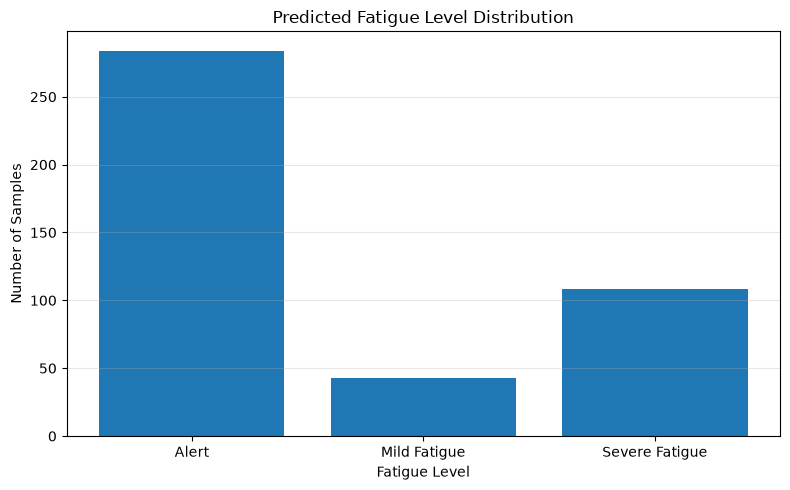

In [9]:

# Cell 9 — Fatigue Level Distribution

fatigue_distribution = (
    analysis_df["fatigue_level"]
    .value_counts()
    .reindex(
        ["Alert", "Mild Fatigue", "Severe Fatigue"],
        fill_value=0
    )
)

display(fatigue_distribution.to_frame("Count"))

plt.figure(figsize=(8, 5))
plt.bar(
    fatigue_distribution.index,
    fatigue_distribution.values
)
plt.xlabel("Fatigue Level")
plt.ylabel("Number of Samples")
plt.title("Predicted Fatigue Level Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:

# Cell 10 — Fatigue Score Distribution

score_distribution = (
    analysis_df["fatigue_score"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
)

print("Fatigue score distribution:")
for score, count in score_distribution.items():
    level = {
        0: "Alert",
        1: "Mild Fatigue",
        2: "Severe Fatigue"
    }[score]
    print(f"{score} ({level}): {count}")


Fatigue score distribution:
0 (Alert): 284
1 (Mild Fatigue): 43
2 (Severe Fatigue): 108



## Sequential Progression Analysis

Because the current dataset does not contain continuous video frames, the following section treats the test-set order as a **sample sequence**.

This demonstrates the progression methodology:

1. Predict each sample.
2. Convert the prediction into a fatigue score.
3. Group samples into fixed analysis windows.
4. Calculate the average fatigue score for each window.
5. Identify changes between fatigue levels.

**Do not interpret the sample index as real elapsed driving time.**


In [11]:

# Cell 11 — Create Sequential Sample Index

analysis_df = analysis_df.reset_index(drop=True)
analysis_df["sequence_index"] = np.arange(1, len(analysis_df) + 1)

print("Sequential analysis created.")
print("First sample:", analysis_df["sequence_index"].iloc[0])
print("Last sample:", analysis_df["sequence_index"].iloc[-1])


Sequential analysis created.
First sample: 1
Last sample: 435


In [12]:

# Cell 12 — Create Fixed Analysis Windows

analysis_df["window"] = (
    (analysis_df["sequence_index"] - 1) // WINDOW_SIZE
) + 1

progression_df = (
    analysis_df
    .groupby("window")
    .agg(
        start_sample=("sequence_index", "min"),
        end_sample=("sequence_index", "max"),
        average_fatigue_score=("fatigue_score", "mean"),
        maximum_fatigue_score=("fatigue_score", "max"),
        severe_count=("fatigue_score", lambda x: (x == 2).sum()),
        mild_count=("fatigue_score", lambda x: (x == 1).sum()),
        alert_count=("fatigue_score", lambda x: (x == 0).sum()),
        average_confidence=("confidence", "mean")
    )
    .reset_index()
)

def score_to_level(score):
    if score < 0.5:
        return "Alert"
    elif score < 1.5:
        return "Mild Fatigue"
    else:
        return "Severe Fatigue"

progression_df["dominant_fatigue_level"] = (
    progression_df["average_fatigue_score"]
    .apply(score_to_level)
)

display(progression_df)


,window,start_sample,end_sample,average_fatigue_score,maximum_fatigue_score,severe_count,mild_count,alert_count,average_confidence,dominant_fatigue_level
0,1,1,30,0.566667,2,7,3,20,0.802736,Mild Fatigue
1,2,31,60,0.700000,2,9,3,18,0.874170,Mild Fatigue
2,3,61,90,0.666667,2,8,4,18,0.807537,Mild Fatigue
3,4,91,120,0.400000,2,3,6,21,0.791052,Alert
4,5,121,150,0.633333,2,8,3,19,0.789969,Mild Fatigue
5,6,151,180,0.766667,2,11,1,18,0.864754,Mild Fatigue
6,7,181,210,0.633333,2,9,1,20,0.825981,Mild Fatigue
7,8,211,240,0.433333,2,6,1,23,0.788709,Alert
8,9,241,270,0.766667,2,9,5,16,0.792769,Mild Fatigue
9,10,271,300,0.333333,2,4,2,24,0.821069,Alert


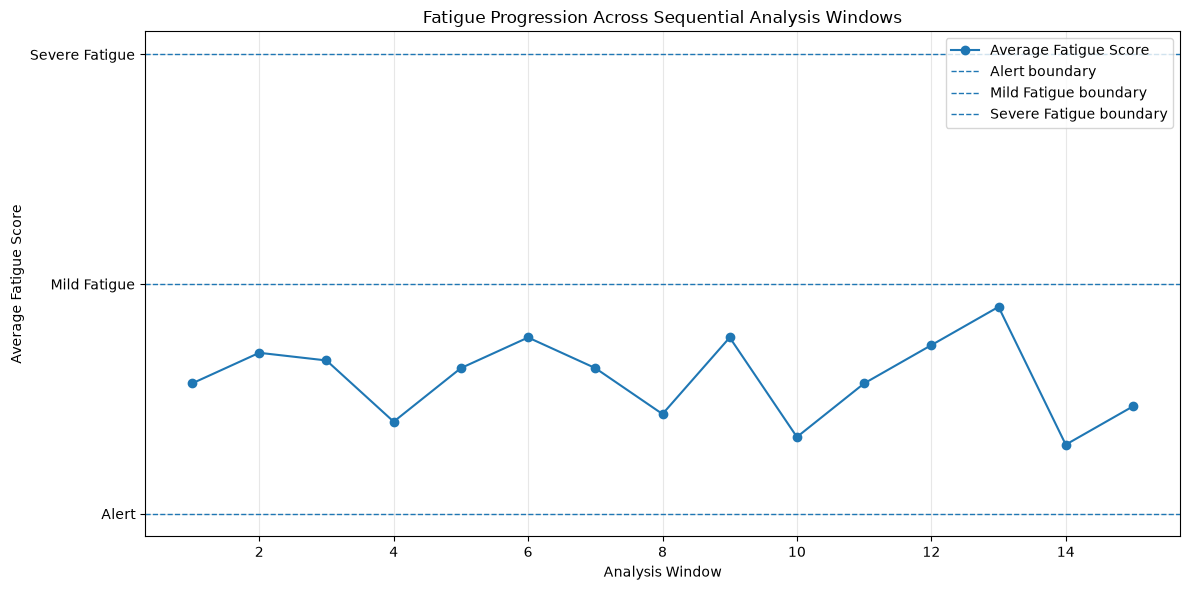

In [13]:

# Cell 13 — Fatigue Progression Curve

plt.figure(figsize=(12, 6))

plt.plot(
    progression_df["window"],
    progression_df["average_fatigue_score"],
    marker="o",
    label="Average Fatigue Score"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    label="Alert boundary"
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1,
    label="Mild Fatigue boundary"
)

plt.axhline(
    2,
    linestyle="--",
    linewidth=1,
    label="Severe Fatigue boundary"
)

plt.xlabel("Analysis Window")
plt.ylabel("Average Fatigue Score")
plt.title("Fatigue Progression Across Sequential Analysis Windows")
plt.yticks([0, 1, 2], ["Alert", "Mild Fatigue", "Severe Fatigue"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:

# Cell 14 — Identify Fatigue Transitions

level_order = {
    "Alert": 0,
    "Mild Fatigue": 1,
    "Severe Fatigue": 2
}

progression_df["level_score"] = (
    progression_df["dominant_fatigue_level"].map(level_order)
)

progression_df["previous_level"] = (
    progression_df["dominant_fatigue_level"].shift(1)
)

transitions = progression_df[
    progression_df["dominant_fatigue_level"]
    != progression_df["previous_level"]
].copy()

transitions = transitions[
    transitions["previous_level"].notna()
]

transitions["transition"] = (
    transitions["previous_level"]
    + " → "
    + transitions["dominant_fatigue_level"]
)

print("Detected fatigue transitions:")

if len(transitions) == 0:
    print("No fatigue-level transitions detected.")
else:
    display(
        transitions[
            [
                "window",
                "transition",
                "average_fatigue_score"
            ]
        ]
    )


Detected fatigue transitions:


,window,transition,average_fatigue_score
3,4,Mild Fatigue → Alert,0.400000
4,5,Alert → Mild Fatigue,0.633333
7,8,Mild Fatigue → Alert,0.433333
8,9,Alert → Mild Fatigue,0.766667
9,10,Mild Fatigue → Alert,0.333333
10,11,Alert → Mild Fatigue,0.566667
13,14,Mild Fatigue → Alert,0.300000


In [15]:

# Cell 15 — Detect Alert → Mild → Severe Progression

upward_transitions = []

for _, row in transitions.iterrows():
    previous_score = level_order[row["previous_level"]]
    current_score = level_order[row["dominant_fatigue_level"]]

    if current_score > previous_score:
        upward_transitions.append(
            {
                "window": row["window"],
                "transition": row["transition"],
                "type": "Increasing fatigue"
            }
        )

upward_df = pd.DataFrame(upward_transitions)

if upward_df.empty:
    print("No increasing fatigue transitions detected in this sample sequence.")
else:
    print("Increasing fatigue transitions:")
    display(upward_df)


Increasing fatigue transitions:


,window,transition,type
0,5,Alert → Mild Fatigue,Increasing fatigue
1,9,Alert → Mild Fatigue,Increasing fatigue
2,11,Alert → Mild Fatigue,Increasing fatigue


,count,mean,min,max
predicted_class,,,,
Closed,108,0.9510,0.6962,0.9998
Open,110,0.9826,0.6489,1.0000
no_yawn,174,0.6632,0.5064,0.7984
yawn,43,0.7384,0.5042,0.8729


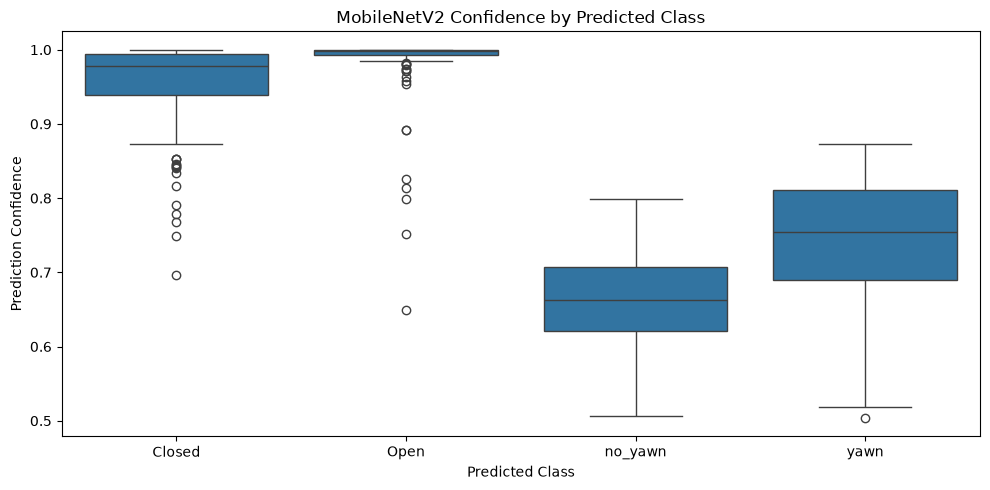

In [16]:

# Cell 16 — Confidence Analysis

confidence_summary = (
    analysis_df
    .groupby("predicted_class")["confidence"]
    .agg(["count", "mean", "min", "max"])
    .reindex(CLASS_NAMES)
)

display(confidence_summary.round(4))

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=analysis_df,
    x="predicted_class",
    y="confidence",
    order=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Prediction Confidence")
plt.title("MobileNetV2 Confidence by Predicted Class")
plt.tight_layout()
plt.show()


In [17]:

# Cell 17 — Show Highest-Risk Predictions

high_risk = (
    analysis_df[
        analysis_df["fatigue_score"] >= 1
    ]
    .sort_values(
        ["fatigue_score", "confidence"],
        ascending=[False, False]
    )
    .head(12)
)

display(
    high_risk[
        [
            "sequence_index",
            "filepath",
            "predicted_class",
            "confidence",
            "fatigue_level",
            "fatigue_score"
        ]
    ]
)


,sequence_index,filepath,predicted_class,confidence,fatigue_level,fatigue_score
372,373,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.999813,Severe Fatigue,2
184,185,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.999338,Severe Fatigue,2
340,341,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.999270,Severe Fatigue,2
364,365,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.999141,Severe Fatigue,2
53,54,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.998962,Severe Fatigue,2
162,163,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.998844,Severe Fatigue,2
241,242,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.998757,Severe Fatigue,2
199,200,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.998713,Severe Fatigue,2
255,256,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.998672,Severe Fatigue,2
186,187,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0.998619,Severe Fatigue,2


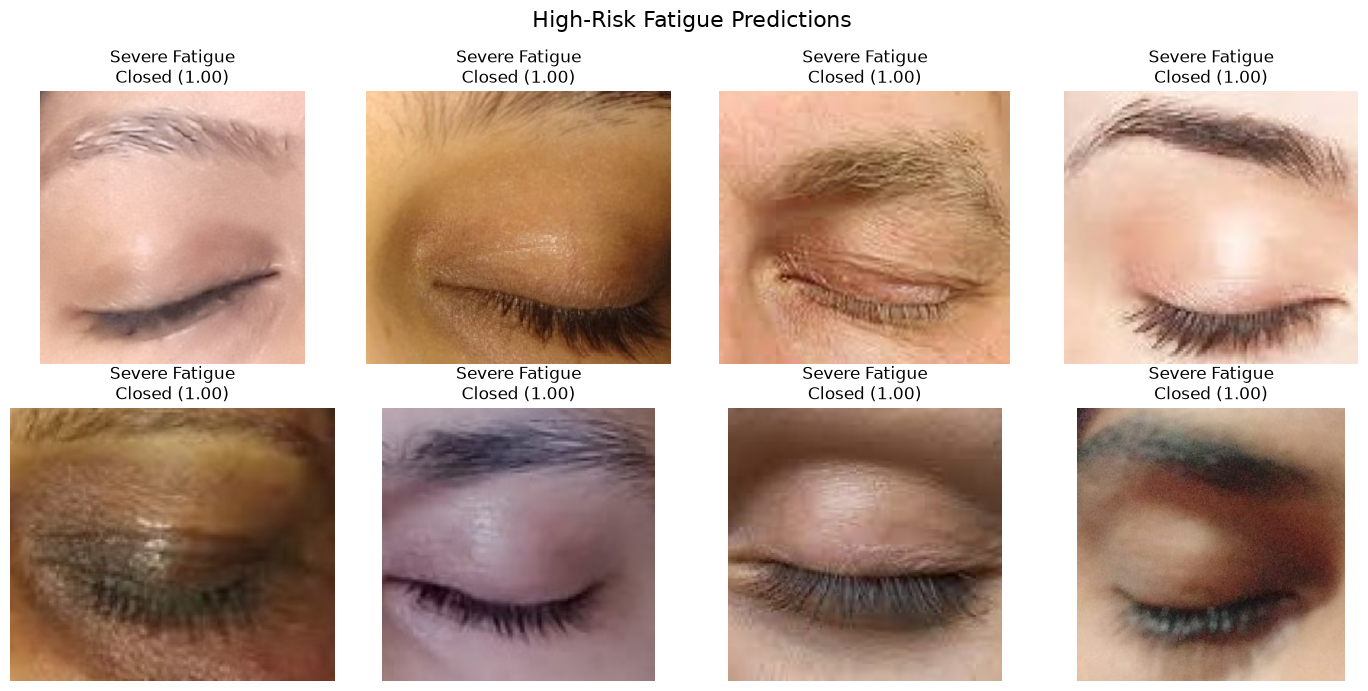

In [18]:

# Cell 18 — Visualize Highest-Risk Predictions

show_count = min(8, len(high_risk))

if show_count > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for i, (_, row) in enumerate(high_risk.head(show_count).iterrows()):
        image = Image.open(row["filepath"]).convert("RGB")

        axes[i].imshow(image)
        axes[i].set_title(
            f"{row['fatigue_level']}\n"
            f"{row['predicted_class']} ({row['confidence']:.2f})"
        )
        axes[i].axis("off")

    for ax in axes[show_count:]:
        ax.axis("off")

    plt.suptitle("High-Risk Fatigue Predictions", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No mild or severe fatigue predictions found.")


In [19]:

# Cell 19 — Save Fatigue Predictions

save_columns = [
    "sequence_index",
    "filepath",
    "label",
    "predicted_class",
    "confidence",
    "fatigue_level",
    "fatigue_score",
    "window"
]

analysis_df[save_columns].to_csv(
    FUSION_OUTPUT_PATH,
    index=False
)

progression_df.drop(
    columns=["level_score", "previous_level"],
    errors="ignore"
).to_csv(
    PROGRESSION_OUTPUT_PATH,
    index=False
)

print("Saved fatigue predictions:")
print(os.path.abspath(FUSION_OUTPUT_PATH))

print("\nSaved progression analysis:")
print(os.path.abspath(PROGRESSION_OUTPUT_PATH))


Saved fatigue predictions:
d:\driver-drowsiness-detection\outputs\fatigue_predictions.csv

Saved progression analysis:
d:\driver-drowsiness-detection\outputs\fatigue_progression.csv



## Final Interpretation

The MobileNetV2 predictions are converted into an application-level fatigue score using an explainable rule-based fusion approach.

- **Alert (0):** Open eyes and/or no yawning.
- **Mild Fatigue (1):** Yawning detected.
- **Severe Fatigue (2):** Closed eyes detected.

The rule-based mapping makes the final fatigue classification easy to explain and trace back to the model's facial-state prediction.

### Important limitation

The current dataset consists of independent images. It cannot establish real temporal fatigue progression by itself. The progression section demonstrates the analysis method using ordered samples. For a production-quality progression analysis, continuous webcam/video frames with timestamps should be processed in sequence.

The main model limitation observed in Notebook 3 is also relevant here: **yawn recall is lower than the other classes**, so some mild-fatigue events may be missed.


In [20]:

# Cell 20 — Final Summary

print("FATIGUE ANALYSIS SUMMARY")
print("=" * 45)

print(f"Total samples analyzed: {len(analysis_df)}")
print(
    f"Alert predictions: "
    f"{(analysis_df['fatigue_score'] == 0).sum()}"
)
print(
    f"Mild Fatigue predictions: "
    f"{(analysis_df['fatigue_score'] == 1).sum()}"
)
print(
    f"Severe Fatigue predictions: "
    f"{(analysis_df['fatigue_score'] == 2).sum()}"
)

print("\nSelected model: MobileNetV2")
print("Fatigue fusion: Explainable rule-based mapping")
print("Progression analysis: Sequential sample-window demonstration")


FATIGUE ANALYSIS SUMMARY
Total samples analyzed: 435
Alert predictions: 284
Mild Fatigue predictions: 43
Severe Fatigue predictions: 108

Selected model: MobileNetV2
Fatigue fusion: Explainable rule-based mapping
Progression analysis: Sequential sample-window demonstration
